In [53]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_rows', None)

import seaborn as sns

data_dir = "/home/alily/Documents/GitHub/TongueTwister/Experiments/TT1/data/alldat"
sub_list = ['sub-02','sub-03','sub-04','sub-05','sub-06']

data = []
for sub in sub_list:
    d=(pd.read_csv(f"{data_dir}/{sub}_alldat.tsv",sep="\t"))
    data.append(d)
data = pd.concat(data, ignore_index=True)
data = data.dropna()



In [54]:
data["ST"] = data["offset_sec"] - data["onset_sec"]


data.head(6)

,subject,run,trial,syllable,wav_file,syllable_number,onset_sec,offset_sec,ST
0,sub-02,1,1,juh,behav_sub-02_run-01_trial-01.wav,1,0.5325,0.6725,0.14
1,sub-02,1,1,juh,behav_sub-02_run-01_trial-01.wav,2,0.6725,0.8525,0.18
2,sub-02,1,1,juh,behav_sub-02_run-01_trial-01.wav,3,0.8525,1.0125,0.16
3,sub-02,1,1,juh,behav_sub-02_run-01_trial-01.wav,4,1.0125,1.2125,0.20
4,sub-02,1,1,juh,behav_sub-02_run-01_trial-01.wav,5,1.2125,1.3725,0.16
5,sub-02,1,1,juh,behav_sub-02_run-01_trial-01.wav,6,1.3725,1.5325,0.16


In [55]:
syllable_medians = data.groupby("syllable")["ST"].median().reset_index()

syllable_medians.head(6)

,syllable,ST
0,a,0.20
1,airy,0.20
2,caw,0.20
3,chuck,0.16
4,day,0.18
5,fee,0.20


In [56]:
times = data[["syllable","ST","wav_file"]].copy()


for index,row in times.iterrows():
    syllable = row["syllable"]
    median = syllable_medians.loc[syllable_medians["syllable"]==syllable,"ST"].values[0]
    times.loc[index,"median"] = median
    times.loc[index,"diff"] = row["ST"] - median

times.head(6)

,syllable,ST,wav_file,median,diff
0,juh,0.14,behav_sub-02_run-01_trial-01.wav,0.2,-6.000000e-02
1,juh,0.18,behav_sub-02_run-01_trial-01.wav,0.2,-2.000000e-02
2,juh,0.16,behav_sub-02_run-01_trial-01.wav,0.2,-4.000000e-02
3,juh,0.20,behav_sub-02_run-01_trial-01.wav,0.2,-2.220446e-16
4,juh,0.16,behav_sub-02_run-01_trial-01.wav,0.2,-4.000000e-02
5,juh,0.16,behav_sub-02_run-01_trial-01.wav,0.2,-4.000000e-02


In [57]:
outliers = times[(times["diff"] > 0.25) | (times["diff"] < -0.25)]

outliers

,syllable,ST,wav_file,median,diff
584,less,0.9000,behav_sub-02_run-01_trial-39.wav,0.20,0.7000
656,out,0.5200,behav_sub-02_run-02_trial-02.wav,0.20,0.3200
1611,if,0.4849,behav_sub-02_run-03_trial-17.wav,0.18,0.3049
2167,less,0.5600,behav_sub-02_run-04_trial-06.wav,0.20,0.3600
2544,picked,0.4600,behav_sub-02_run-04_trial-28.wav,0.20,0.2600
3467,less,0.9400,behav_sub-02_run-05_trial-39.wav,0.20,0.7400
3544,less,0.7200,behav_sub-02_run-06_trial-02.wav,0.20,0.5200
3548,less,0.6400,behav_sub-02_run-06_trial-02.wav,0.20,0.4400
4674,less,0.5200,behav_sub-02_run-07_trial-23.wav,0.20,0.3200
5324,thrilled,0.5800,behav_sub-02_run-08_trial-17.wav,0.24,0.3400


In [58]:
import numpy as np

def is_outlier_zscore(group):
    mean = group.mean()
    std = group.std()
    z_scores = (group - mean) / std
    return np.abs(z_scores) > 3.0

# Apply per category
data['Is_Outlier_Z'] = data.groupby('syllable')['ST'].transform(is_outlier_zscore)
data[data['Is_Outlier_Z']]

,subject,run,trial,syllable,wav_file,syllable_number,onset_sec,offset_sec,ST,Is_Outlier_Z
406,sub-02,1,27,pro,behav_sub-02_run-01_trial-27.wav,10,3.3725,3.7925,0.4200,True
584,sub-02,1,39,less,behav_sub-02_run-01_trial-39.wav,13,3.8525,4.7525,0.9000,True
656,sub-02,2,2,out,behav_sub-02_run-02_trial-02.wav,4,1.2925,1.8125,0.5200,True
962,sub-02,2,20,pro,behav_sub-02_run-02_trial-20.wav,6,2.2925,2.7125,0.4200,True
1611,sub-02,3,17,if,behav_sub-02_run-03_trial-17.wav,20,4.5125,4.9974,0.4849,True
2511,sub-02,4,26,leh,behav_sub-02_run-04_trial-26.wav,18,4.5325,4.9974,0.4649,True
3467,sub-02,5,39,less,behav_sub-02_run-05_trial-39.wav,14,3.4725,4.4125,0.9400,True
3544,sub-02,6,2,less,behav_sub-02_run-06_trial-02.wav,8,2.4525,3.1725,0.7200,True
3548,sub-02,6,2,less,behav_sub-02_run-06_trial-02.wav,12,3.8925,4.5325,0.6400,True
6252,sub-03,1,31,naw,behav_sub-03_run-01_trial-31.wav,4,1.8525,2.3725,0.5200,True


<Axes: xlabel='syllable', ylabel='ST'>

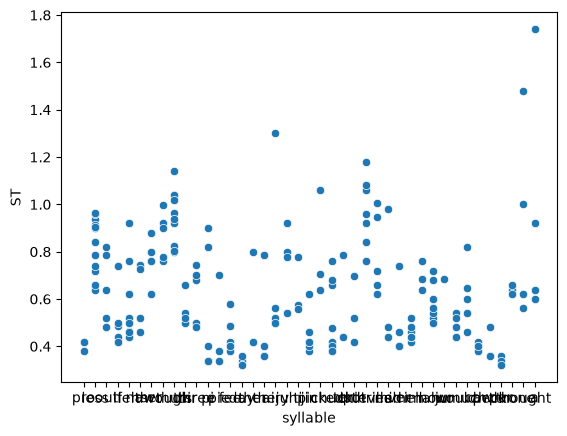

In [29]:
sns.scatterplot(data=data[data['Is_Outlier_Z']==True], x="syllable", y="ST")